In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dipole = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/dipole_moments.csv'))
structures = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/structures.csv'))
scalar_coupling_contributions = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/scalar_coupling_contributions.csv'))
magnetic_shielding_tensors = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/magnetic_shielding_tensors.csv'))
mulliken_charges = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/mulliken_charges.csv'))
potential_energy = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/potential_energy.csv'))
samples = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/sample_submission.csv'))
test = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/test.csv'))
train = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/train.csv'))


In [4]:
dipole 

,molecule_name,X,Y,Z
0,dsgdb9nsd_000001,0.0000,0.0000,0.0000
1,dsgdb9nsd_000002,-0.0002,0.0000,1.6256
2,dsgdb9nsd_000003,0.0000,0.0000,-1.8511
3,dsgdb9nsd_000004,0.0000,0.0000,0.0000
4,dsgdb9nsd_000005,0.0000,0.0000,-2.8937
...,...,...,...,...
130784,dsgdb9nsd_133881,1.2590,0.1153,-1.0814
130785,dsgdb9nsd_133882,-0.3710,-1.2435,0.0000
130786,dsgdb9nsd_133883,-0.4359,1.1694,-0.0000
130787,dsgdb9nsd_133884,1.3623,1.4058,-0.0000


In [15]:
structures

,molecule_name,atom_index,atom,x,y,z
0,dsgdb9nsd_000001,0,C,-0.012698,1.085804,0.008001
1,dsgdb9nsd_000001,1,H,0.002150,-0.006031,0.001976
2,dsgdb9nsd_000001,2,H,1.011731,1.463751,0.000277
3,dsgdb9nsd_000001,3,H,-0.540815,1.447527,-0.876644
4,dsgdb9nsd_000001,4,H,-0.523814,1.437933,0.906397
...,...,...,...,...,...,...
2358870,dsgdb9nsd_133885,11,H,-1.454004,-0.967309,1.459246
2358871,dsgdb9nsd_133885,12,H,0.277779,-2.697872,0.195770
2358872,dsgdb9nsd_133885,13,H,2.515854,-1.151784,0.527369
2358873,dsgdb9nsd_133885,14,H,0.013699,1.199431,-1.680192


In [7]:
scalar_coupling_contributions

,molecule_name,atom_index_0,atom_index_1,type,fc,sd,pso,dso
0,dsgdb9nsd_000001,1,0,1JHC,83.022400,0.254579,1.258620,0.272010
1,dsgdb9nsd_000001,1,2,2JHH,-11.034700,0.352978,2.858390,-3.433600
2,dsgdb9nsd_000001,1,3,2JHH,-11.032500,0.352944,2.858520,-3.433870
3,dsgdb9nsd_000001,1,4,2JHH,-11.031900,0.352934,2.858550,-3.433930
4,dsgdb9nsd_000001,2,0,1JHC,83.022200,0.254585,1.258610,0.272013
...,...,...,...,...,...,...,...,...
4659071,dsgdb9nsd_133884,17,4,2JHC,3.586440,0.019741,0.150477,-0.213205
4659072,dsgdb9nsd_133884,17,5,3JHC,0.674583,-0.007276,0.305078,-0.403388
4659073,dsgdb9nsd_133884,17,6,3JHC,1.337470,-0.028423,0.312240,-0.447920
4659074,dsgdb9nsd_133884,17,7,2JHC,4.800620,0.139202,-0.053102,-0.124710


In [8]:
magnetic_shielding_tensors

,molecule_name,atom_index,XX,YX,ZX,XY,YY,ZY,XZ,YZ,ZZ
0,dsgdb9nsd_000001,0,195.3147,0.0000,-0.0001,0.0000,195.3171,0.0007,-0.0001,0.0007,195.3169
1,dsgdb9nsd_000001,1,31.3410,-1.2317,4.0544,-1.2317,28.9546,-1.7173,4.0546,-1.7173,34.0861
2,dsgdb9nsd_000001,2,31.5814,1.2173,-4.1474,1.2173,28.9036,-1.6036,-4.1476,-1.6036,33.8967
3,dsgdb9nsd_000001,3,31.5172,4.1086,1.2723,4.1088,33.9068,1.6950,1.2724,1.6951,28.9579
4,dsgdb9nsd_000001,4,31.4029,-4.0942,-1.1793,-4.0944,34.0776,1.6259,-1.1795,1.6260,28.9013
...,...,...,...,...,...,...,...,...,...,...,...
2358870,dsgdb9nsd_133885,11,28.6323,-0.1148,-2.2990,1.9651,24.5294,-2.4469,-2.0840,0.8863,33.2278
2358871,dsgdb9nsd_133885,12,31.2449,6.1929,6.3054,3.8977,29.1150,5.6072,2.3143,3.7461,29.7163
2358872,dsgdb9nsd_133885,13,33.8789,-3.6278,0.0001,0.6389,25.2816,-0.0000,-0.0001,0.0000,22.4285
2358873,dsgdb9nsd_133885,14,28.6324,-0.1148,2.2990,1.9652,24.5294,2.4471,2.0840,-0.8863,33.2278


In [9]:
mulliken_charges

,molecule_name,atom_index,mulliken_charge
0,dsgdb9nsd_000001,0,-0.535689
1,dsgdb9nsd_000001,1,0.133921
2,dsgdb9nsd_000001,2,0.133922
3,dsgdb9nsd_000001,3,0.133923
4,dsgdb9nsd_000001,4,0.133923
...,...,...,...
2358870,dsgdb9nsd_133885,11,0.078144
2358871,dsgdb9nsd_133885,12,0.099332
2358872,dsgdb9nsd_133885,13,0.114018
2358873,dsgdb9nsd_133885,14,0.078144


In [10]:
potential_energy

,molecule_name,potential_energy
0,dsgdb9nsd_000001,-40.523680
1,dsgdb9nsd_000002,-56.560246
2,dsgdb9nsd_000003,-76.426077
3,dsgdb9nsd_000004,-77.335268
4,dsgdb9nsd_000005,-93.428488
...,...,...
130784,dsgdb9nsd_133881,-400.761274
130785,dsgdb9nsd_133882,-400.757209
130786,dsgdb9nsd_133883,-380.894376
130787,dsgdb9nsd_133884,-364.872596


In [11]:
samples

,id,scalar_coupling_constant
0,4659076,0
1,4659077,0
2,4659078,0
3,4659079,0
4,4659080,0
...,...,...
2505185,7164261,0
2505186,7164262,0
2505187,7164263,0
2505188,7164264,0


In [12]:
test

,id,molecule_name,atom_index_0,atom_index_1,type
0,4659076,dsgdb9nsd_000004,2,0,2JHC
1,4659077,dsgdb9nsd_000004,2,1,1JHC
2,4659078,dsgdb9nsd_000004,2,3,3JHH
3,4659079,dsgdb9nsd_000004,3,0,1JHC
4,4659080,dsgdb9nsd_000004,3,1,2JHC
...,...,...,...,...,...
2505185,7164261,dsgdb9nsd_133885,15,3,2JHC
2505186,7164262,dsgdb9nsd_133885,15,4,2JHC
2505187,7164263,dsgdb9nsd_133885,15,6,3JHC
2505188,7164264,dsgdb9nsd_133885,15,7,2JHC


In [13]:
train

,id,molecule_name,atom_index_0,atom_index_1,type,scalar_coupling_constant
0,0,dsgdb9nsd_000001,1,0,1JHC,84.807600
1,1,dsgdb9nsd_000001,1,2,2JHH,-11.257000
2,2,dsgdb9nsd_000001,1,3,2JHH,-11.254800
3,3,dsgdb9nsd_000001,1,4,2JHH,-11.254300
4,4,dsgdb9nsd_000001,2,0,1JHC,84.807400
...,...,...,...,...,...,...
4659071,4659071,dsgdb9nsd_133884,17,4,2JHC,3.543450
4659072,4659072,dsgdb9nsd_133884,17,5,3JHC,0.568997
4659073,4659073,dsgdb9nsd_133884,17,6,3JHC,1.173370
4659074,4659074,dsgdb9nsd_133884,17,7,2JHC,4.762010


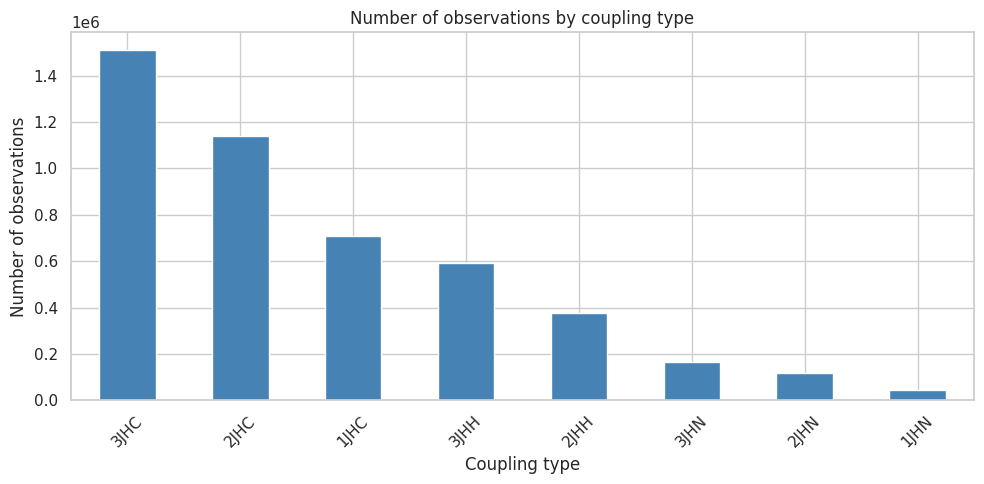

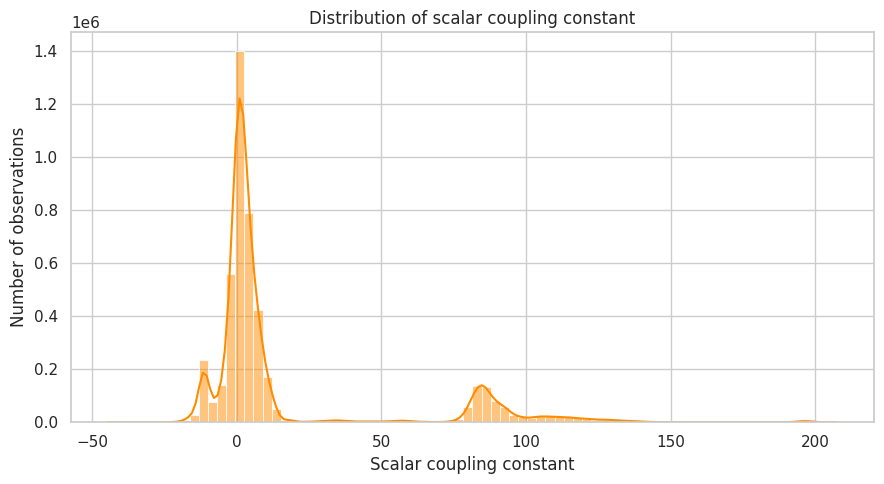

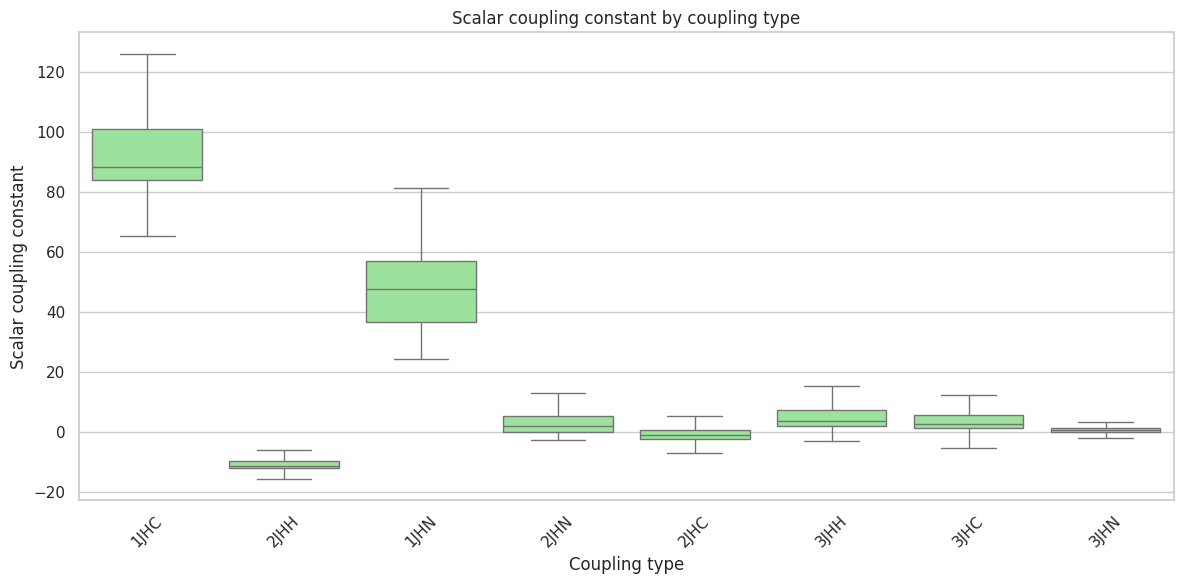

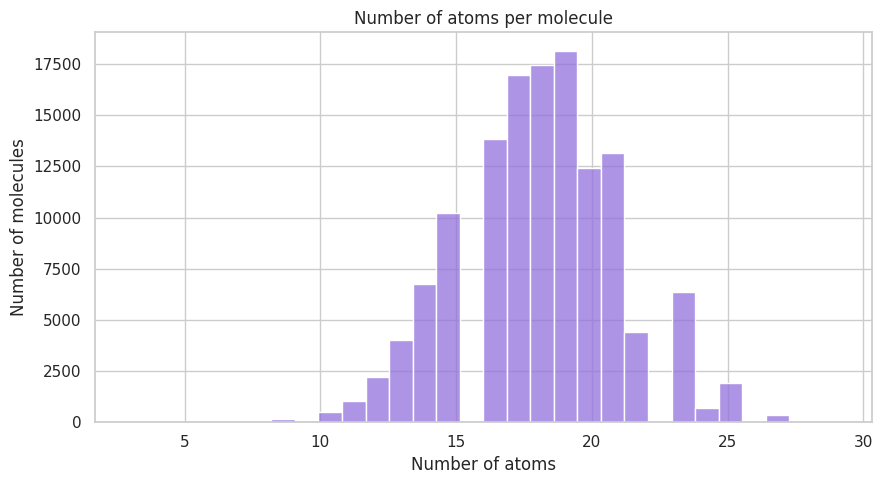

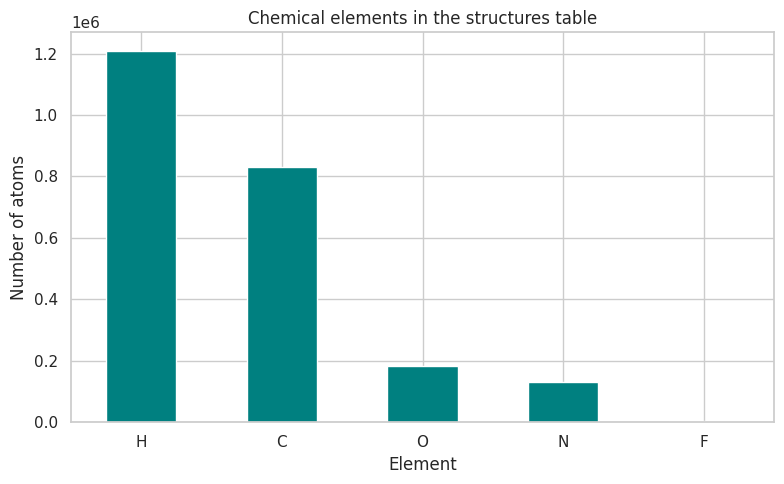

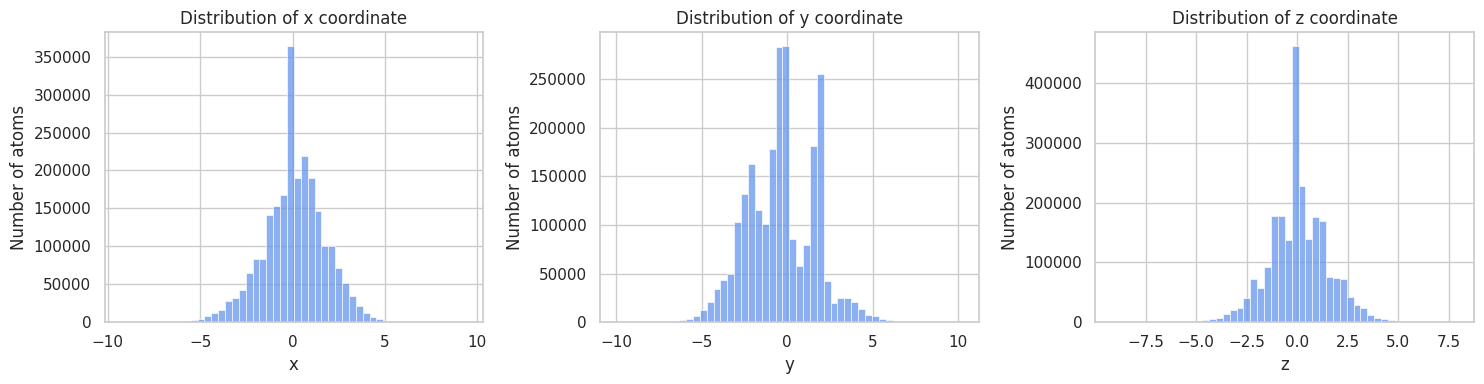

In [16]:
# Plot 1: number of observations for each coupling type
plt.figure(figsize=(10, 5))
train['type'].value_counts().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Number of observations by coupling type')
plt.xlabel('Coupling type')
plt.ylabel('Number of observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: distribution of the target value
plt.figure(figsize=(9, 5))
sns.histplot(train['scalar_coupling_constant'], bins=80, kde=True, color='darkorange')
plt.title('Distribution of scalar coupling constant')
plt.xlabel('Scalar coupling constant')
plt.ylabel('Number of observations')
plt.tight_layout()
plt.show()

# Plot 3: target values for each coupling type
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='type', y='scalar_coupling_constant', showfliers=False, color='lightgreen')
plt.title('Scalar coupling constant by coupling type')
plt.xlabel('Coupling type')
plt.ylabel('Scalar coupling constant')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 4: number of atoms in each molecule
atoms_per_molecule = structures.groupby('molecule_name')['atom_index'].nunique()
plt.figure(figsize=(9, 5))
sns.histplot(atoms_per_molecule, bins=30, color='mediumpurple')
plt.title('Number of atoms per molecule')
plt.xlabel('Number of atoms')
plt.ylabel('Number of molecules')
plt.tight_layout()
plt.show()

# Plot 5: frequency of chemical elements
plt.figure(figsize=(8, 5))
structures['atom'].value_counts().plot(kind='bar', color='teal')
plt.title('Chemical elements in the structures table')
plt.xlabel('Element')
plt.ylabel('Number of atoms')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 6: distribution of atom coordinates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['x', 'y', 'z']):
    sns.histplot(structures[column], bins=50, ax=axis, color='cornflowerblue')
    axis.set_title(f'Distribution of {column} coordinate')
    axis.set_xlabel(column)
    axis.set_ylabel('Number of atoms')
plt.tight_layout()
plt.show()

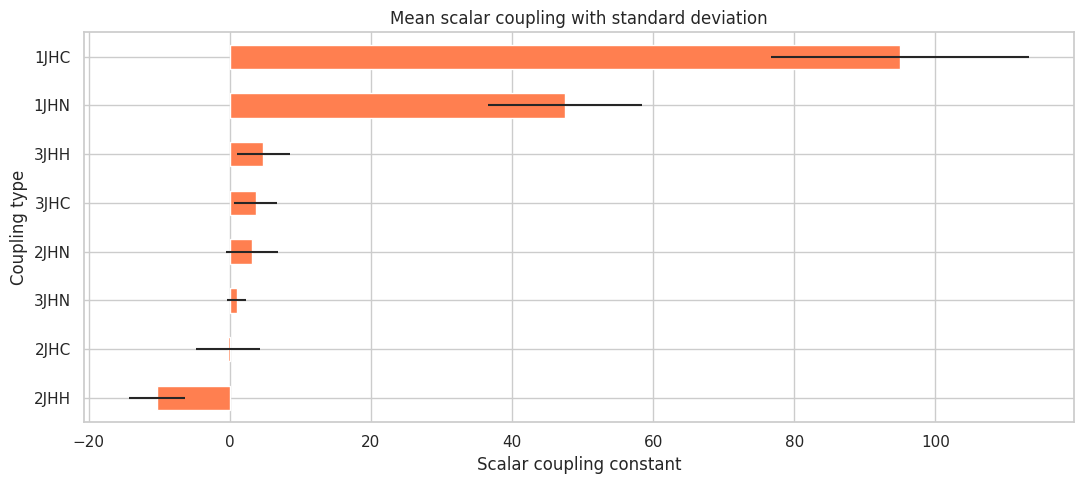

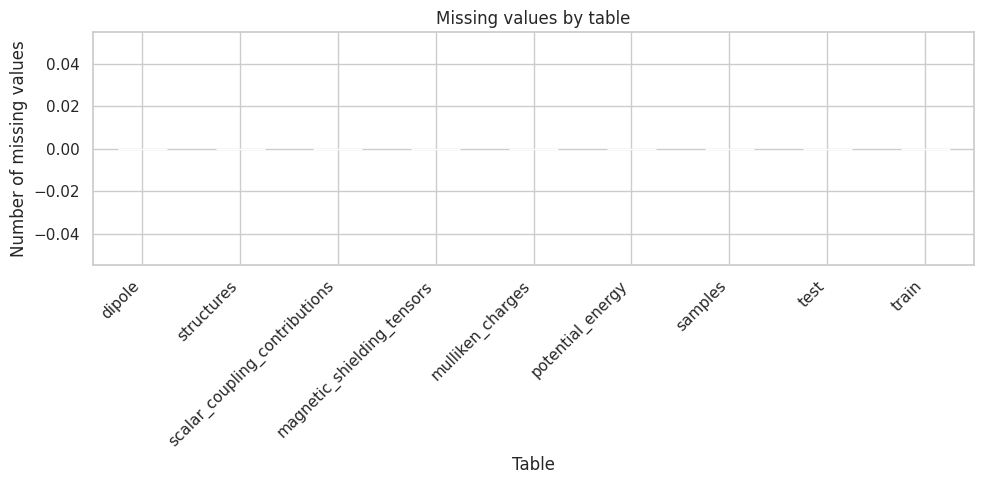

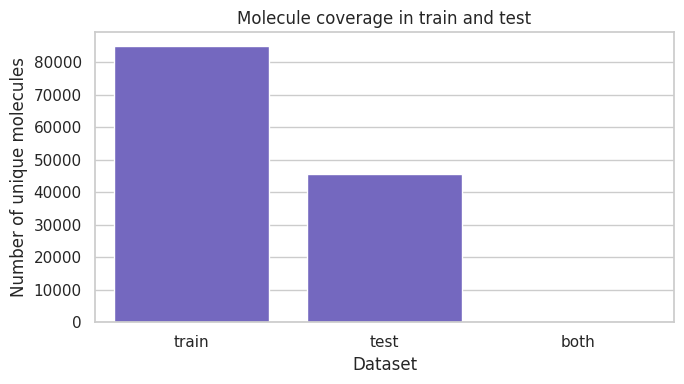

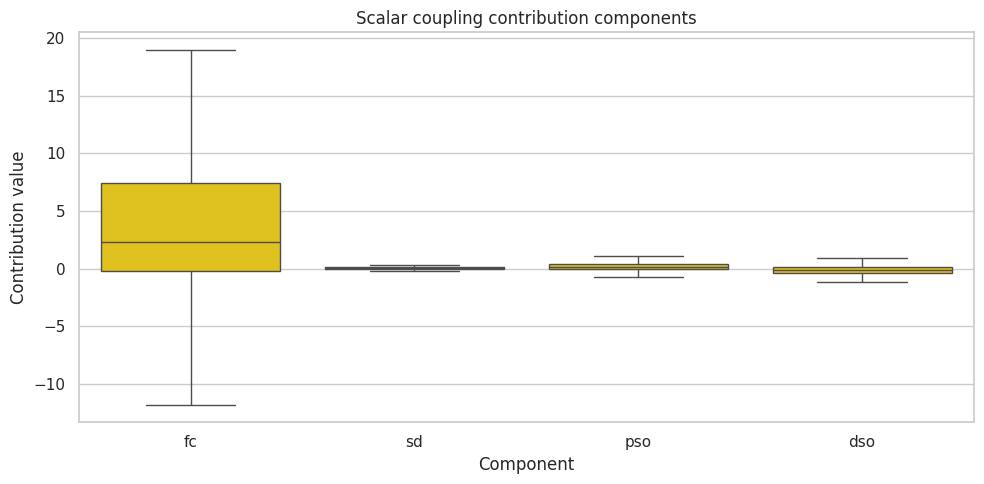

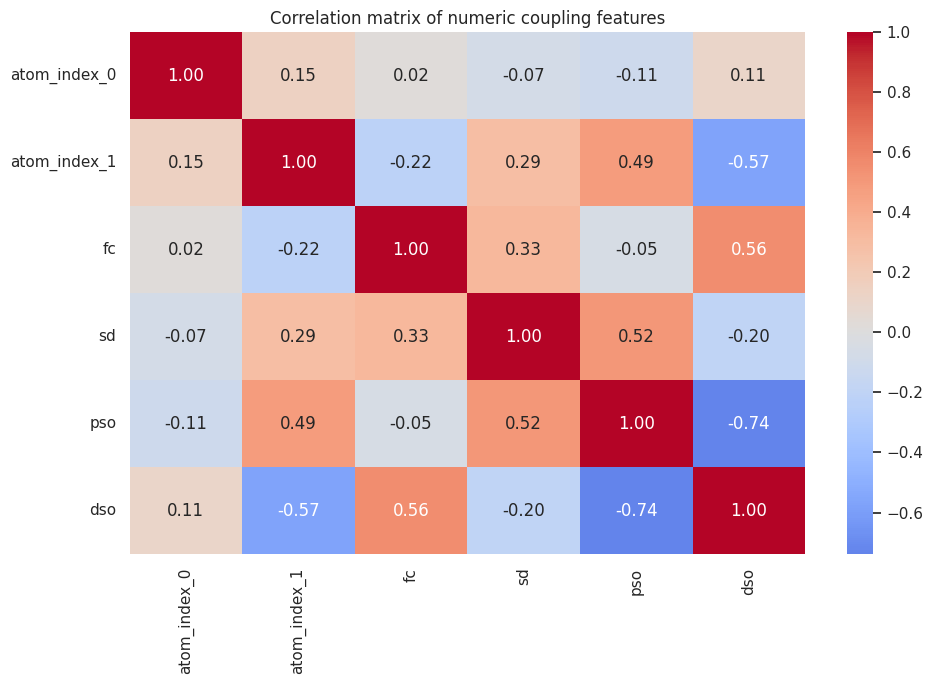

In [17]:
# Table 1: size and missing values for all tables
table_summary = pd.DataFrame({
    'rows': {name: frame.shape[0] for name, frame in {
        'dipole': dipole,
        'structures': structures,
        'scalar_coupling_contributions': scalar_coupling_contributions,
        'magnetic_shielding_tensors': magnetic_shielding_tensors,
        'mulliken_charges': mulliken_charges,
        'potential_energy': potential_energy,
        'samples': samples,
        'test': test,
        'train': train
    }.items()},
    'columns': {name: frame.shape[1] for name, frame in {
        'dipole': dipole,
        'structures': structures,
        'scalar_coupling_contributions': scalar_coupling_contributions,
        'magnetic_shielding_tensors': magnetic_shielding_tensors,
        'mulliken_charges': mulliken_charges,
        'potential_energy': potential_energy,
        'samples': samples,
        'test': test,
        'train': train
    }.items()},
    'missing_values': {name: frame.isna().sum().sum() for name, frame in {
        'dipole': dipole,
        'structures': structures,
        'scalar_coupling_contributions': scalar_coupling_contributions,
        'magnetic_shielding_tensors': magnetic_shielding_tensors,
        'mulliken_charges': mulliken_charges,
        'potential_energy': potential_energy,
        'samples': samples,
        'test': test,
        'train': train
    }.items()}
})
table_summary

# Table 2: target statistics by coupling type
target_by_type = train.groupby('type')['scalar_coupling_constant'].agg(
    count='count', mean='mean', median='median', std='std', minimum='min', maximum='max'
).sort_values('count', ascending=False)
target_by_type

# Plot 7: target mean and standard deviation by coupling type
plt.figure(figsize=(11, 5))
target_by_type['mean'].sort_values().plot(kind='barh', xerr=target_by_type.loc[target_by_type['mean'].sort_values().index, 'std'], color='coral')
plt.title('Mean scalar coupling with standard deviation')
plt.xlabel('Scalar coupling constant')
plt.ylabel('Coupling type')
plt.tight_layout()
plt.show()

# Plot 8: missing values in every table
missing_by_table = table_summary['missing_values'].sort_values(ascending=False)
plt.figure(figsize=(10, 5))
missing_by_table.plot(kind='bar', color='firebrick')
plt.title('Missing values by table')
plt.xlabel('Table')
plt.ylabel('Number of missing values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Table 3: train and test molecule coverage
train_molecules = set(train['molecule_name'])
test_molecules = set(test['molecule_name'])
molecule_coverage = pd.DataFrame({
    'dataset': ['train', 'test', 'both'],
    'molecules': [len(train_molecules), len(test_molecules), len(train_molecules & test_molecules)]
})
molecule_coverage

# Plot 9: train and test molecule coverage
plt.figure(figsize=(7, 4))
sns.barplot(data=molecule_coverage, x='dataset', y='molecules', color='slateblue')
plt.title('Molecule coverage in train and test')
plt.xlabel('Dataset')
plt.ylabel('Number of unique molecules')
plt.tight_layout()
plt.show()

# Table 4: average molecular properties
molecule_properties = structures.groupby('molecule_name').agg(
    atom_count=('atom_index', 'nunique'),
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    mean_z=('z', 'mean')
)
molecule_properties.describe().T

# Plot 10: coupling contribution components
contribution_columns = [column for column in ['fc', 'sd', 'pso', 'dso'] if column in scalar_coupling_contributions.columns]
if contribution_columns:
    contribution_sample = scalar_coupling_contributions[contribution_columns].sample(
        min(100000, len(scalar_coupling_contributions)), random_state=42
    )
    contribution_long = contribution_sample.melt(var_name='component', value_name='value')
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=contribution_long, x='component', y='value', showfliers=False, color='gold')
    plt.title('Scalar coupling contribution components')
    plt.xlabel('Component')
    plt.ylabel('Contribution value')
    plt.tight_layout()
    plt.show()

# Plot 11: correlation between numeric coupling features
numeric_columns = scalar_coupling_contributions.select_dtypes(include=np.number).columns
correlation = scalar_coupling_contributions[numeric_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation matrix of numeric coupling features')
plt.tight_layout()
plt.show()

Columns in potential_energy: ['molecule_name', 'potential_energy']
Kinetic energy is not available in this dataset.
Velocities and atomic masses are needed to calculate it.


,potential_energy
count,130789.000000
mean,-410.951413
std,39.839916
min,-714.626197
25%,-438.002671
50%,-416.920943
75%,-387.221827
max,-40.523680


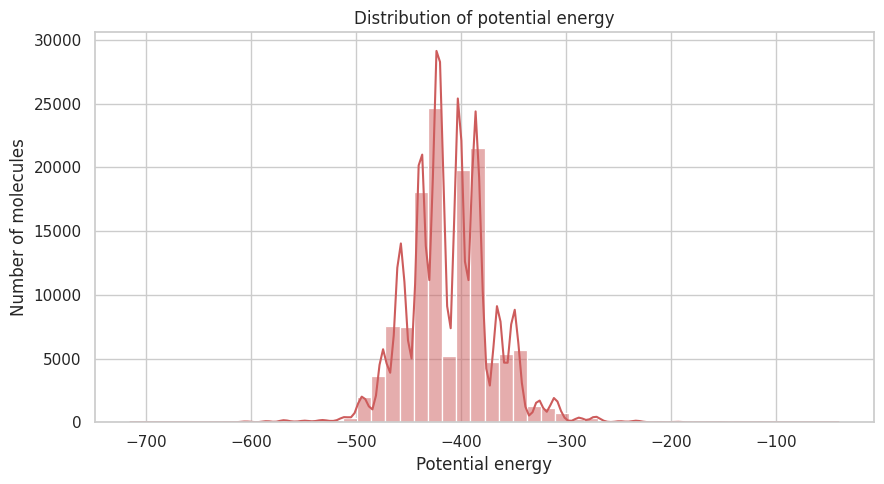

In [18]:
# Energy analysis
energy_columns = potential_energy.columns.tolist()
print('Columns in potential_energy:', energy_columns)

kinetic_columns = [column for column in energy_columns if 'kinetic' in column.lower()]
if kinetic_columns:
    print('Kinetic energy columns:', kinetic_columns)
else:
    print('Kinetic energy is not available in this dataset.')
    print('Velocities and atomic masses are needed to calculate it.')

potential_column = [column for column in energy_columns if 'potential' in column.lower()]
if potential_column:
    potential_column = potential_column[0]
    potential_summary = potential_energy[potential_column].describe().to_frame('potential_energy')
    display(potential_summary)

    plt.figure(figsize=(9, 5))
    sns.histplot(potential_energy[potential_column], bins=50, kde=True, color='indianred')
    plt.title('Distribution of potential energy')
    plt.xlabel('Potential energy')
    plt.ylabel('Number of molecules')
    plt.tight_layout()
    plt.show()
else:
    print('A potential energy value column was not found.')

Shape: (2358875, 11)
Columns: ['molecule_name', 'atom_index', 'XX', 'YX', 'ZX', 'XY', 'YY', 'ZY', 'XZ', 'YZ', 'ZZ']
Missing values: 0


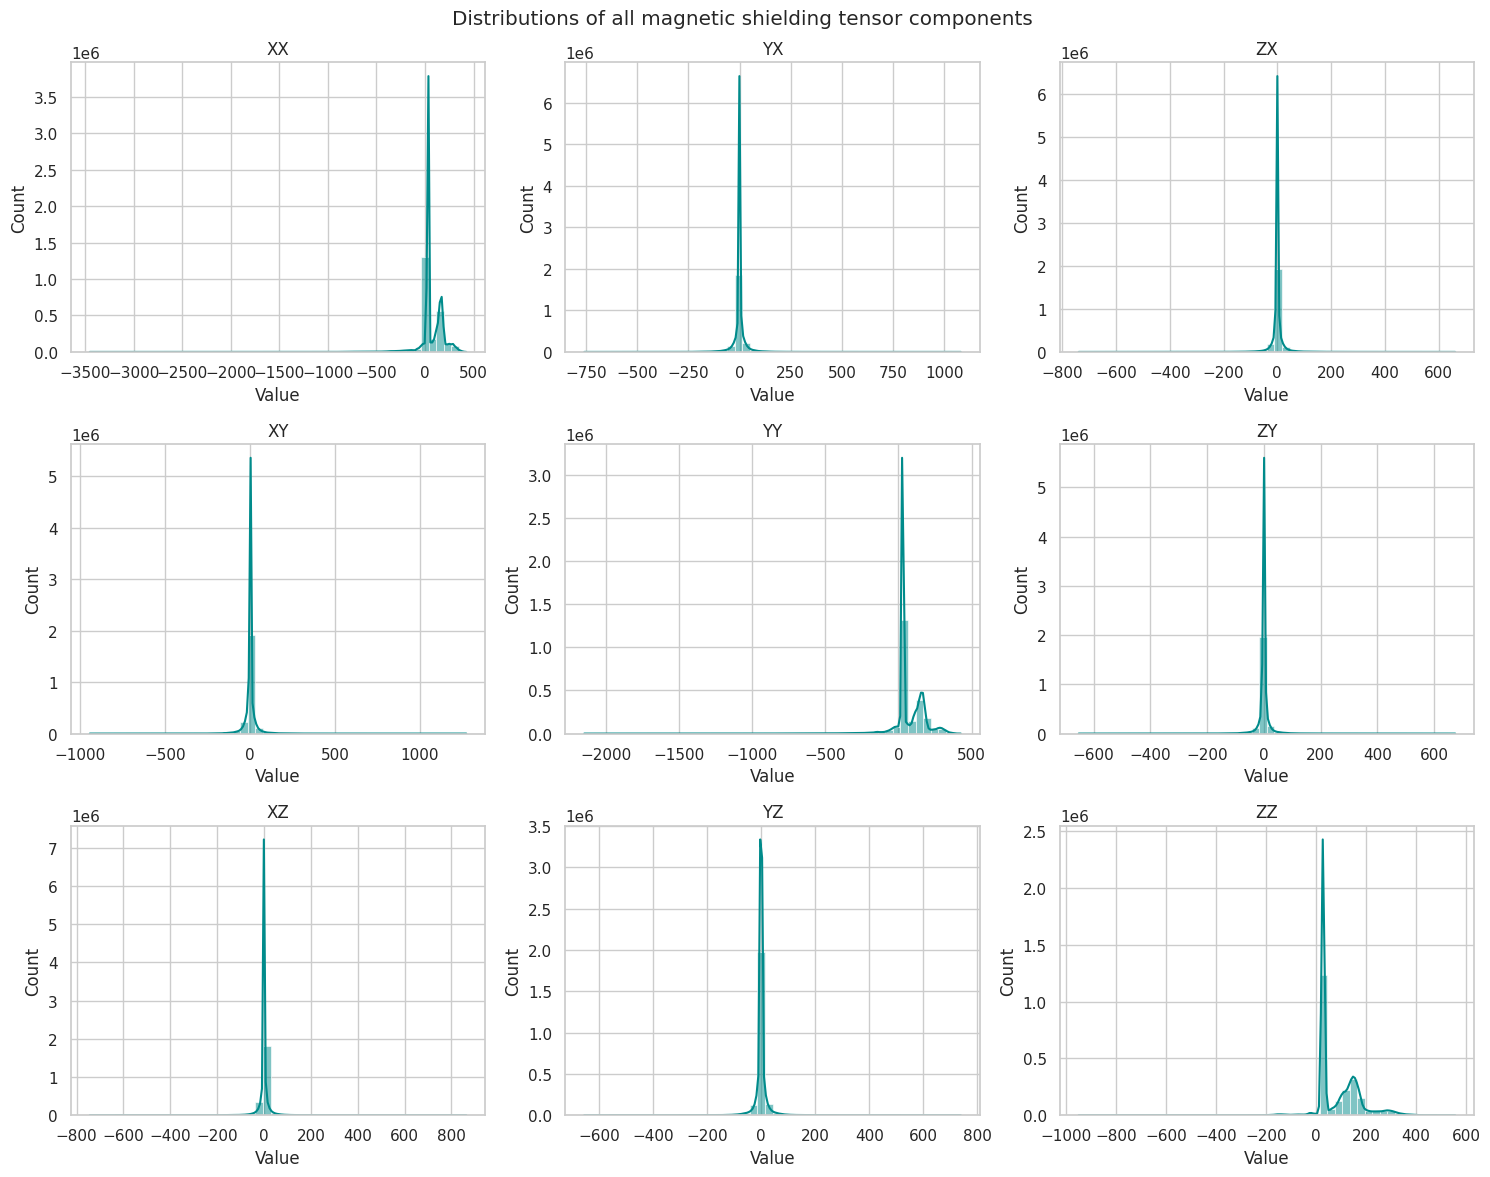

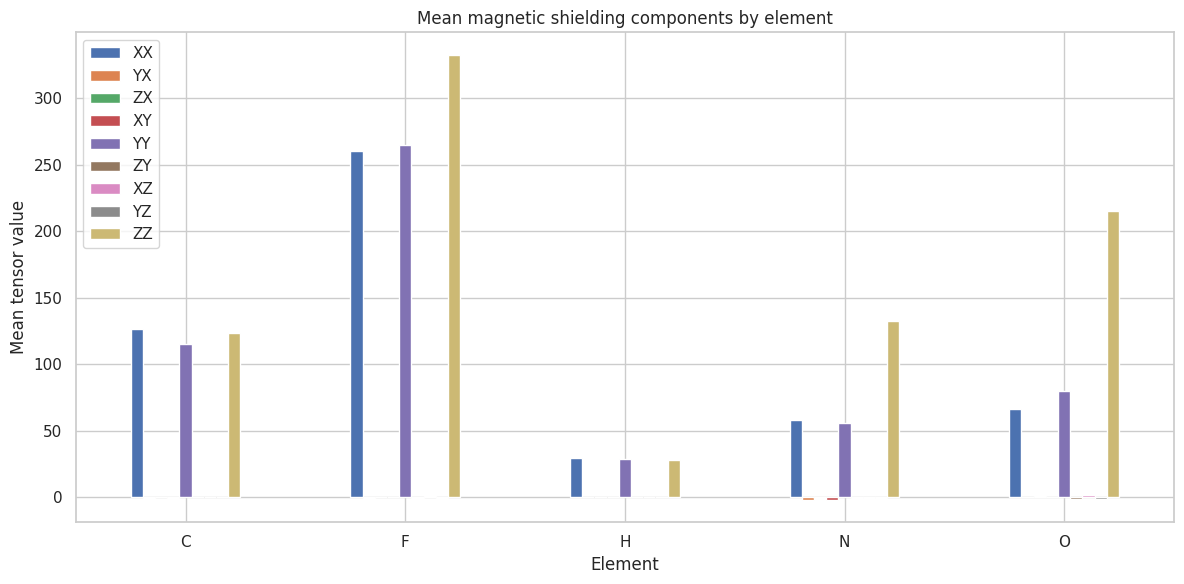

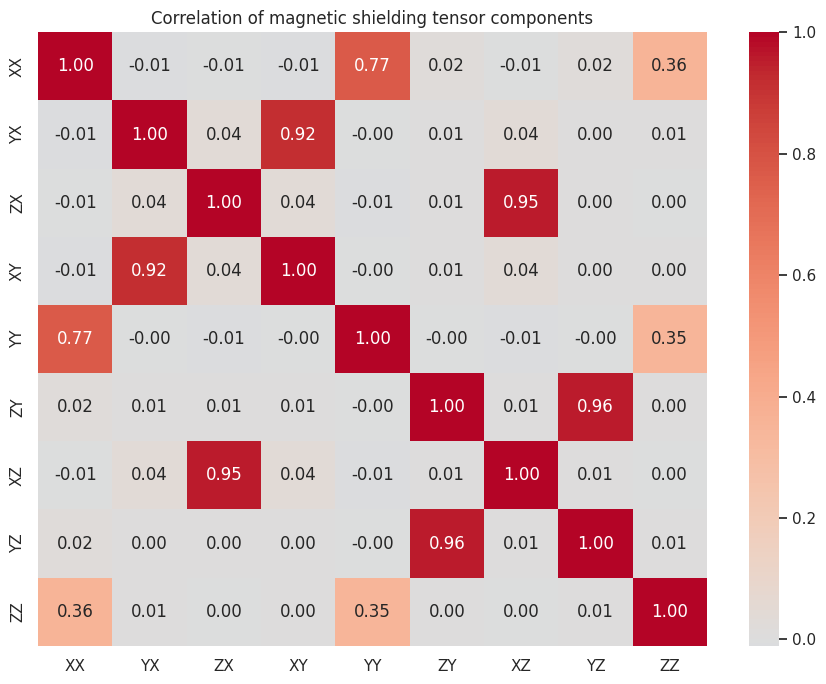

In [20]:
# Magnetic shielding tensors
print('Shape:', magnetic_shielding_tensors.shape)
print('Columns:', magnetic_shielding_tensors.columns.tolist())
print('Missing values:', magnetic_shielding_tensors.isna().sum().sum())

shielding_numeric = magnetic_shielding_tensors.select_dtypes(include=np.number).columns.tolist()
shielding_numeric = [column for column in shielding_numeric if column != 'atom_index']

shielding_summary = magnetic_shielding_tensors[shielding_numeric].describe().T
shielding_summary

# Add the chemical element to each tensor row
shielding_with_atom = magnetic_shielding_tensors.merge(
    structures[['molecule_name', 'atom_index', 'atom']],
    on=['molecule_name', 'atom_index'],
    how='left'
)

atom_summary = shielding_with_atom.groupby('atom')[shielding_numeric].mean().round(3)
atom_summary

# Distributions of all tensor components
if shielding_numeric:
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.ravel()
    for axis, column in zip(axes, shielding_numeric):
        sns.histplot(magnetic_shielding_tensors[column], bins=50, kde=True, ax=axis, color='darkcyan')
        axis.set_title(column)
        axis.set_xlabel('Value')
        axis.set_ylabel('Count')
    plt.suptitle('Distributions of all magnetic shielding tensor components')
    plt.tight_layout()
    plt.show()

# Mean tensor components by chemical element
if 'atom' in shielding_with_atom.columns and shielding_numeric:
    atom_summary.plot(kind='bar', figsize=(12, 6))
    plt.title('Mean magnetic shielding components by element')
    plt.xlabel('Element')
    plt.ylabel('Mean tensor value')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Correlation between tensor components
if len(shielding_numeric) > 1:
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        magnetic_shielding_tensors[shielding_numeric].corr(),
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        center=0
    )
    plt.title('Correlation of magnetic shielding tensor components')
    plt.tight_layout()
    plt.show()